In [247]:
import pandas as pd

df = pd.read_csv("./sleep_cycle_productivity.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           42 non-null     object 
 1   Person_ID                      42 non-null     int64  
 2   Age                            42 non-null     int64  
 3   Gender                         42 non-null     object 
 4   Sleep Start Time               42 non-null     float64
 5   Sleep End Time                 42 non-null     float64
 6   Total Sleep Hours              42 non-null     float64
 7   Sleep Quality                  42 non-null     int64  
 8   Exercise (mins/day)            42 non-null     int64  
 9   Caffeine Intake (mg)           42 non-null     int64  
 10  Screen Time Before Bed (mins)  42 non-null     int64  
 11  Work Hours (hrs/day)           42 non-null     float64
 12  Productivity Score             42 non-null     int64

,Date,Person_ID,Age,Gender,Sleep Start Time,Sleep End Time,Total Sleep Hours,Sleep Quality,Exercise (mins/day),Caffeine Intake (mg),Screen Time Before Bed (mins),Work Hours (hrs/day),Productivity Score,Mood Score,Stress Level
0,2025-02-01,1,25,M,23.0,7.0,8.0,7,45,100,60,2.0,30,6,8
1,2025-02-02,2,30,F,22.5,6.5,8.0,8,50,150,50,3.0,50,7,6
2,2025-02-03,3,28,M,23.5,6.5,7.0,6,30,200,70,4.0,65,5,7
3,2025-02-04,4,35,F,22.0,6.0,8.0,9,60,80,40,5.0,80,8,5
4,2025-02-05,5,40,M,23.0,5.5,6.5,5,20,250,90,6.0,85,4,9


In [248]:
X = df[["Work Hours (hrs/day)"]]
y = df["Productivity Score"]

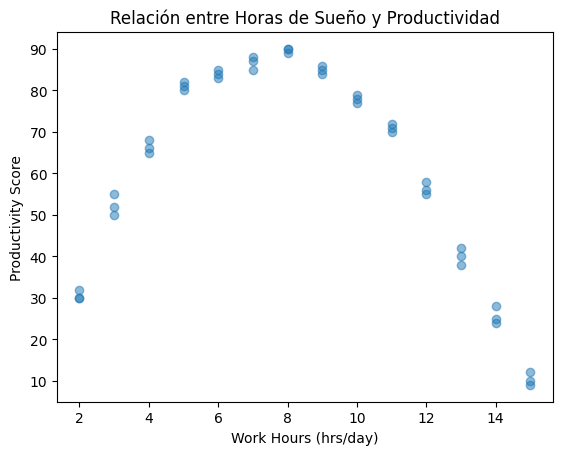

In [249]:
import matplotlib.pyplot as plt

plt.scatter(X, y, alpha=0.5)
plt.xlabel("Work Hours (hrs/day)")
plt.ylabel("Productivity Score")
plt.title("Relación entre Horas de Sueño y Productividad")
plt.show()

In [268]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer

num_columns = ["Work Hours (hrs/day)"]

preprocessor = ColumnTransformer([
    ("num", PolynomialFeatures(2), num_columns)
])

X_transformed = preprocessor.fit_transform(X)
X_transformed = pd.DataFrame(X_transformed)
X_transformed.head()

,0,1,2
0,1.0,2.0,4.0
1,1.0,3.0,9.0
2,1.0,4.0,16.0
3,1.0,5.0,25.0
4,1.0,6.0,36.0


In [269]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from statsmodels.miscmodels.ordinal_model import OrderedModel


X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=1997)

reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred = reg.predict(X_test)

y_pred

array([82.73684422, 26.46868853, 44.68547431,  5.05668379, 75.39187841,
       71.53338904, 75.39187841, 59.70704115, 59.70704115])

In [270]:
residuals = y_test - y_pred
pd.Series(residuals)

4     2.263156
12   -1.468689
39   -6.685474
27    6.943316
31    5.608122
37   -0.533389
3     4.608122
38   -3.707041
10   -4.707041
Name: Productivity Score, dtype: float64

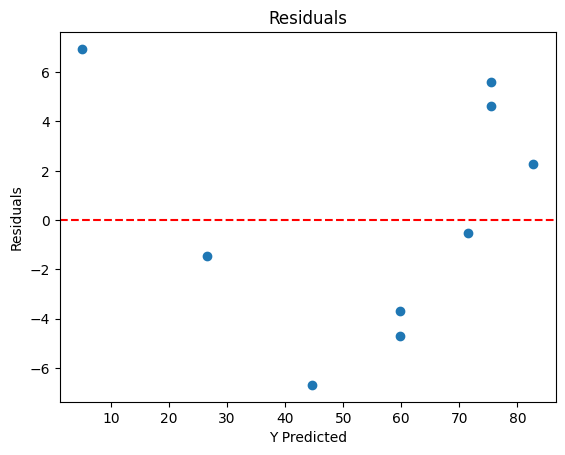

In [271]:
import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals)
plt.title("Residuals")
plt.xlabel("Y Predicted")
plt.ylabel("Residuals")
plt.axhline(0, linestyle="--", color="r")
plt.show()

In [272]:
from sklearn.metrics import r2_score

print("R^2", r2_score(y_test, y_pred))

R^2 0.9655571760724455


In [273]:
import statsmodels.api as sm

X_with_const = sm.add_constant(X_transformed)

X_opt = X_with_const.iloc[:, :]
reg_OLS = sm.OLS(endog = y, exog = X_opt).fit()
reg_OLS.summary()

# X_opt = X_with_const.iloc[:, [0, 6]]
# reg_OLS = sm.OLS(endog = y, exog = X_opt).fit()
# reg_OLS.summary()

/Users/angelozambrano/Library/Caches/pypoetry/virtualenvs/machine-learning-course-4d5qHaxw-py3.12/lib/python3.12/site-packages/statsmodels/tsa/tsatools.py:162: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  x = pd.concat(x[::order], axis=1)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     Productivity Score   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     1214.
Date:                Mon, 24 Feb 2025   Prob (F-statistic):           7.60e-36
Time:                        16:56:45   Log-Likelihood:                -107.57
No. Observations:                  42   AIC:                             221.1
Df Residuals:                      39   BIC:                             226.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
0             -7.6967      2.274     -3.385      0.002     -12.295      -3.098
1             24.6115      0.605     40.713      0.000      23.389      25.834
2             -1.5852      0.035    -45.555      0.000      -1.656      -1.515
==============================================================================
Omnibus:                        0.477   Durbin-Watson:                   1.613
Prob(Omnibus):                  0.788   Jarque-Bera (JB):                0.561
Skew:                           0.228   Prob(JB):                        0.755
Kurtosis:                       2.664   Cond. No.                         529.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [283]:
print(reg.predict([[1, 50, 50**2]]))

[-2757.35142059]
